<a href="https://colab.research.google.com/github/nadiduno/CienciaDeDados-BootCampFly/blob/main/estat_stica_visualiza_o_de_dados_aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Estatística e Visualização de Dados na Prática
## *Do dado bruto ao insight — aula de 2 horas*

---

> **Para quem é esta aula?**  
> Para quem está começando a trabalhar com dados e quer entender, de verdade, o que as métricas significam — não só calcular, mas **interpretar**.

**🗺️ O que vamos aprender hoje:**

| # | Tópico | O que você vai conseguir fazer |
|---|--------|-------------------------------|
| 1 | Tipos de dados | Identificar o tipo certo antes de qualquer análise |
| 2 | Média, Mediana e Moda | Escolher a medida certa para cada situação |
| 3 | Outliers | Reconhecer quando um valor extremo distorce os resultados |
| 4 | Variância e Desvio Padrão | Medir e interpretar a dispersão dos dados |
| 5 | Visualizações | Criar o gráfico certo para cada pergunta |
| 6 | Distribuições | Identificar o perfil dos dados e suas implicações |
| 7 | Correlação e Causalidade | Medir relações entre variáveis sem cair em armadilhas |

---

**Ferramentas que vamos usar:**
- `pandas` → manipula dados em tabelas (DataFrames)
- `numpy` → operações matemáticas rápidas
- `matplotlib` e `seaborn` → visualizações
- `scipy.stats` → distribuições e testes estatísticos

---
## ⚙️ Célula 0 — Rode esta primeira!

Antes de qualquer coisa, precisamos carregar as ferramentas.
Em Python, fazemos isso com `import`. Cole este bloco no início de todo notebook de análise.

In [ ]:
# Carregando as bibliotecas que vamos usar durante toda a aula
import numpy as np          # numpy: operações matemáticas em conjuntos de números
import pandas as pd         # pandas: manipula dados em tabelas (como planilhas)

import matplotlib.pyplot as plt   # matplotlib: base para criar gráficos
import seaborn as sns             # seaborn: gráficos estatísticos com visual melhorado

from scipy import stats           # scipy: funções estatísticas avançadas (distribuições, testes)

# Configurações de visual — deixam os gráficos mais limpos e padronizados
sns.set_theme(style='whitegrid')   # fundo com grade branca, mais fácil de ler
plt.rcParams['figure.figsize'] = (9, 4)  # tamanho padrão dos gráficos (9 de largo, 4 de alto)

# Semente aleatória: garante que os números gerados sejam sempre os mesmos
# (importante para reproduzir resultados em sala)
np.random.seed(42)

print('✅ Bibliotecas carregadas! Podemos começar.')

✅ Bibliotecas carregadas! Podemos começar.


---
## 📂 Seção 1 — Tipos de Dados

**Antes de calcular qualquer coisa, identifique o tipo do dado.**
O tipo define o que faz sentido fazer: calcular a 'média de bairros' não faz sentido. Mas calcular a 'média de idades', sim.

| Tipo | Subtipo | Exemplos | O que podemos fazer |
|------|---------|----------|---------------------|
| **Quantitativo** | Discreto (contagem) | Nº de filhos, gols, pedidos | Média, mediana, soma |
| **Quantitativo** | Contínuo (medição) | Altura, salário, temperatura | Média, mediana, desvio padrão |
| **Qualitativo** | Nominal (sem ordem) | Bairro, cor favorita, marca | Contar, moda |
| **Qualitativo** | Ordinal (com ordem) | Grau escolar, avaliação 1–5 | Contar, moda, mediana |

> 🚨 **Erro clássico:** Codificar bairros como 1, 2, 3 e calcular a "média dos bairros".
> O resultado seria "bairro 2,3" — que não significa nada.
> **Tipo errado → análise inválida.**

In [ ]:
# ── Criando nossa primeira tabela de dados (DataFrame) ───────────────────────
#
# Imagine que você trabalha numa empresa de cosméticos.
# Você recebeu os dados de 10 clientes de uma pesquisa.
# Vamos criar essa tabela com pd.DataFrame().

df = pd.DataFrame({
    # Coluna com os nomes das clientes (texto = qualitativo nominal)
    'nome':         ['Ana','Bia','Carol','Diana','Eva','Fran','Gabi','Helena','Iris','Julia'],

    # Idade em anos — número inteiro que resulta de contagem (quantitativo discreto)
    'idade':        [28, 34, 25, 42, 31, 29, 38, 22, 45, 33],

    # Gasto mensal em R$ — pode ter centavos, é uma medição (quantitativo contínuo)
    'gasto_mensal': [320, 580, 210, 950, 430, 380, 720, 180, 1100, 510],

    # Bairro onde mora — categoria sem ordem entre si (qualitativo nominal)
    'bairro':       ['Pinheiros','Vila Madalena','Mooca','Pinheiros','Lapa',
                     'Mooca','Vila Madalena','Centro','Pinheiros','Lapa'],

    # Nota de satisfação de 1 a 5 — tem ordem (qualitativo ordinal)
    'satisfacao':   [4, 5, 3, 5, 4, 2, 5, 3, 4, 5]
})

# .head() mostra as primeiras 5 linhas — sempre bom começar olhando os dados
df.head()

,nome,idade,gasto_mensal,bairro,satisfacao
0,Ana,28,320,Pinheiros,4
1,Bia,34,580,Vila Madalena,5
2,Carol,25,210,Mooca,3
3,Diana,42,950,Pinheiros,5
4,Eva,31,430,Lapa,4


In [ ]:
# ── Conhecendo a tabela: tipos, tamanho e resumo ─────────────────────────────

# .shape mostra (linhas, colunas) — quantas linhas e colunas tem a tabela
print(f'Tamanho da tabela: {df.shape[0]} linhas × {df.shape[1]} colunas')
print()

# .dtypes mostra o tipo que o pandas identificou em cada coluna
# int64 = número inteiro | float64 = número decimal | object = texto
print('Tipos de dado por coluna:')
print(df.dtypes)
print()

# .describe() gera um resumo automático das colunas NUMÉRICAS
# Mostra: contagem, média, desvio padrão, mínimo, quartis e máximo
print('Resumo estatístico das colunas numéricas:')
df.describe().round(1)

Tamanho da tabela: 10 linhas × 5 colunas

Tipos de dado por coluna:
nome            object
idade            int64
gasto_mensal     int64
bairro          object
satisfacao       int64
dtype: object

Resumo estatístico das colunas numéricas:


,idade,gasto_mensal,satisfacao
count,10.0,10.0,10.0
mean,32.7,538.0,4.0
std,7.3,305.7,1.1
min,22.0,180.0,2.0
25%,28.2,335.0,3.2
50%,32.0,470.0,4.0
75%,37.0,685.0,5.0
max,45.0,1100.0,5.0


Clientes por bairro:
bairro
Pinheiros        3
Vila Madalena    2
Mooca            2
Lapa             2
Centro           1
Name: count, dtype: int64

Distribuição das avaliações de satisfação (1=ruim, 5=ótimo):
satisfacao
2    1
3    2
4    3
5    4
Name: count, dtype: int64



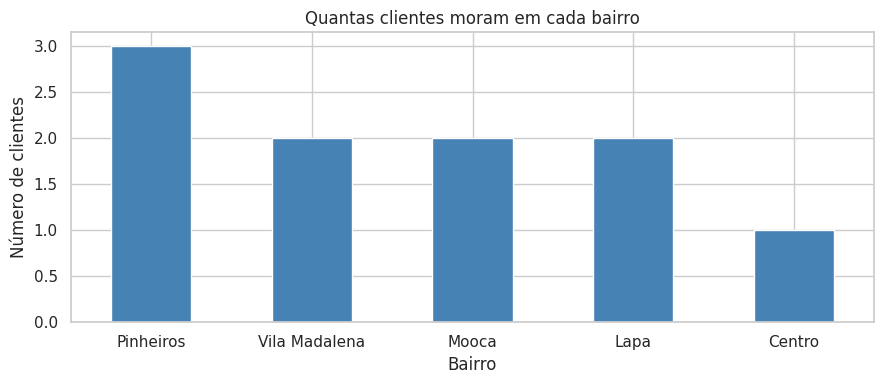

O bairro que aparece mais vezes é a MODA — o mais frequente.


In [ ]:
# ── Explorando dados qualitativos (categóricos) ──────────────────────────────

# Para dados qualitativos, a operação mais útil é contar quantas vezes
# cada categoria aparece. Usamos .value_counts() para isso.

# Contando clientes por bairro
frequencia_bairro = df['bairro'].value_counts()   # .value_counts() ordena do mais frequente ao menos
print('Clientes por bairro:')
print(frequencia_bairro)
print()

# Contando avaliações de satisfação
# sort_index() ordena pelo índice (1→5) em vez de pela frequência
frequencia_satisfacao = df['satisfacao'].value_counts().sort_index()
print('Distribuição das avaliações de satisfação (1=ruim, 5=ótimo):')
print(frequencia_satisfacao)
print()

# Visualizando a frequência de bairros num gráfico de barras simples
frequencia_bairro.plot(kind='bar',          # 'bar' = barras verticais
                       color='steelblue',   # cor das barras
                       edgecolor='white')   # borda branca entre as barras

plt.title('Quantas clientes moram em cada bairro')   # título do gráfico
plt.xlabel('Bairro')                                  # rótulo do eixo X
plt.ylabel('Número de clientes')                      # rótulo do eixo Y
plt.xticks(rotation=0)                                # mantém os textos do eixo X na horizontal
plt.tight_layout()  # ajusta margens para nada ficar cortado
plt.show()          # exibe o gráfico

print('O bairro que aparece mais vezes é a MODA — o mais frequente.')

---
## 📊 Seção 2 — Média, Mediana e Moda

As três medidas de **tendência central** — cada uma responde à pergunta *'qual é o valor típico?'* de um jeito diferente.

| Medida | Como calcula | Ponto forte | Cuidado |
|--------|-------------|-------------|---------|
| **Média** | Soma tudo ÷ quantidade | Intuitiva, usa todos os dados | Sensível a valores extremos |
| **Mediana** | Valor do meio (dados ordenados) | Resistente a valores extremos | Ignora a magnitude dos extremos |
| **Moda** | Valor que aparece mais vezes | Funciona para categóricos | Pode não ser única |

### A fórmula da média:
$$\bar{x} = \frac{x_1 + x_2 + x_3 + \ldots + x_n}{n}$$

Onde: $\bar{x}$ é a média, $x_i$ são os valores e $n$ é a quantidade total.

In [ ]:
# ── Calculando as 3 medidas — gastos semanais da Lara ────────────────────────
#
# Cenário: Lara é designer freelancer.
# Ela registrou seus gastos com transporte de segunda a domingo.
# Nos fins de semana ela não trabalha, então gastou R$0.

# pd.Series cria uma lista de valores com índice personalizado (os dias da semana)
gastos = pd.Series(
    [85, 120, 60, 90, 75, 0, 0],
    index=['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom'],
    name='gastos_R$'
)

# .mean() soma todos os valores e divide pela quantidade
media = gastos.mean()

# .median() ordena os dados e pega o valor do meio
mediana = gastos.median()

# .mode() encontra o valor que aparece mais vezes
# Retorna uma Series, por isso usamos [0] para pegar o primeiro (mais frequente)
moda = gastos.mode()[0]

print('Gastos da Lara por dia:')
print(gastos.to_string())   # .to_string() formata melhor para o print
print()
print(f'Soma total dos gastos:  R$ {gastos.sum():.2f}')
print()
print(f'📊 Média:   R$ {media:.2f}  → soma ÷ 7 dias (incluindo R$0 do fds)')
print(f'📊 Mediana: R$ {mediana:.2f}  → valor do meio quando ordenamos os 7 dias')
print(f'📊 Moda:    R$ {moda:.2f}   → valor que mais se repete (R$0 aparece 2 vezes)')

Gastos da Lara por dia:
Seg     85
Ter    120
Qua     60
Qui     90
Sex     75
Sab      0
Dom      0

Soma total dos gastos:  R$ 430.00

📊 Média:   R$ 61.43  → soma ÷ 7 dias (incluindo R$0 do fds)
📊 Mediana: R$ 75.00  → valor do meio quando ordenamos os 7 dias
📊 Moda:    R$ 0.00   → valor que mais se repete (R$0 aparece 2 vezes)


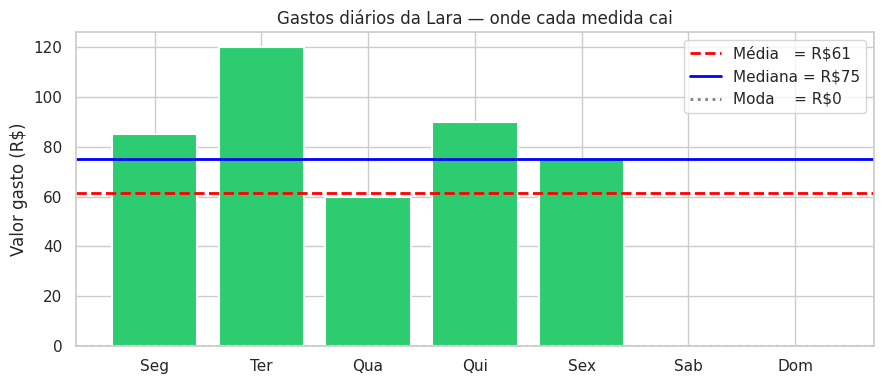

💡 Perceba:
   A média (R$61) foi puxada para baixo pelos dois dias com R$0.
   A mediana (R$75) representa melhor um dia típico de trabalho.
   Neste caso, a mediana é mais honesta do que a média.


In [ ]:
# ── Visualizando as 3 medidas: gráfico de barras com linhas de referência ────
#
# Cada barra é um dia. As linhas horizontais mostram onde cada medida cai.
# Isso revela visualmente por que a medida certa importa.

# Definindo cores: verde para dias com gasto, cinza para dias sem gasto
# A list comprehension abaixo percorre cada gasto e escolhe a cor
cores_dias = ['#2ecc71' if gasto > 0 else '#bdc3c7' for gasto in gastos]
# Lê-se: 'para cada gasto na lista, se for maior que 0 use verde, senão use cinza'

# Criando o gráfico de barras
plt.figure(figsize=(9, 4))   # cria uma área de gráfico com as dimensões definidas
plt.bar(gastos.index,        # eixo X: os dias da semana (índice da Series)
        gastos.values,       # eixo Y: os valores dos gastos
        color=cores_dias,    # cor de cada barra
        edgecolor='white',   # borda branca entre as barras
        linewidth=1.5)       # espessura da borda

# axhline() desenha uma linha horizontal em toda a largura do gráfico
# linestyle='--' = tracejado | linewidth = espessura | label = texto da legenda
plt.axhline(media,   color='red',  linestyle='--', linewidth=2, label=f'Média   = R${media:.0f}')
plt.axhline(mediana, color='blue', linestyle='-',  linewidth=2, label=f'Mediana = R${mediana:.0f}')
plt.axhline(moda,    color='gray', linestyle=':',  linewidth=2, label=f'Moda    = R${moda:.0f}')

plt.title('Gastos diários da Lara — onde cada medida cai', fontsize=12)
plt.ylabel('Valor gasto (R$)')
plt.legend()         # exibe a legenda com os labels que definimos acima
plt.tight_layout()
plt.show()

print('💡 Perceba:')
print(f'   A média (R${media:.0f}) foi puxada para baixo pelos dois dias com R$0.')
print(f'   A mediana (R${mediana:.0f}) representa melhor um dia típico de trabalho.')
print('   Neste caso, a mediana é mais honesta do que a média.')

=== Moda aplicada aos dados dos clientes ===

Bairro mais comum (moda): Pinheiros — 3 clientes

Nota de satisfação mais frequente (moda): 5 estrelas



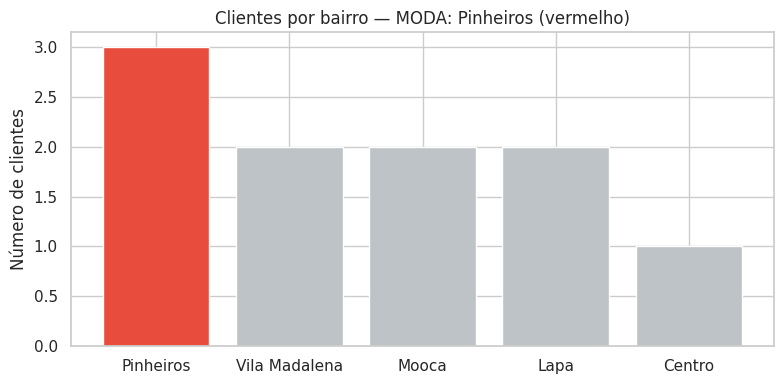

In [ ]:
# ── Moda: a única medida que funciona para dados qualitativos ────────────────
#
# Para dados como bairro, cor favorita, produto mais vendido —
# não faz sentido calcular média ou mediana.
# A moda (valor mais frequente) é a única medida adequada.

print('=== Moda aplicada aos dados dos clientes ===')
print()

# Moda do bairro: qual bairro aparece mais nas nossas clientes?
frequencia = df['bairro'].value_counts()  # conta cada bairro
bairro_moda = frequencia.index[0]         # o primeiro da lista é o mais frequente
qtd_moda    = frequencia.iloc[0]          # .iloc[0] pega o valor da primeira posição

print(f'Bairro mais comum (moda): {bairro_moda} — {qtd_moda} clientes')
print()

# Moda da satisfação: qual nota de 1 a 5 foi mais dada?
satisfacao_moda = df['satisfacao'].mode()[0]
print(f'Nota de satisfação mais frequente (moda): {satisfacao_moda} estrelas')
print()

# Visualizando a moda de forma clara
cores_barras = ['#e74c3c' if bairro == bairro_moda else '#bdc3c7'
                for bairro in frequencia.index]
# A barra vermelha é a moda, as cinzas são os outros bairros

plt.figure(figsize=(8, 4))
plt.bar(frequencia.index,    # eixo X: os bairros
        frequencia.values,   # eixo Y: quantas clientes de cada bairro
        color=cores_barras,  # destaque vermelho na moda
        edgecolor='white')

plt.title(f'Clientes por bairro — MODA: {bairro_moda} (vermelho)', fontsize=12)
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

---
## 🦢 Seção 3 — Outliers: quando um valor distorce tudo

**Outlier** = valor que se afasta muito do padrão do restante dos dados.

Pode ser:
- Um erro de digitação (R\$1.000 virou R\$100.000)
- Um caso genuinamente excepcional (salário da CEO numa empresa)
- Um evento pontual e único (venda enorme num dia de promoção)

**O problema:** a **média** é a medida mais sensível a outliers.
Um único valor extremo pode fazer a média saltar para um número que não representa ninguém.

| Situação | Medida adequada |
|----------|----------------|
| Dados homogêneos, sem extremos | Média |
| Há valores extremos (outliers) | **Mediana** |
| Dados categóricos | Moda |

In [ ]:
# ── O impacto do outlier na média — salários de uma startup ──────────────────
#
# A startup tem 8 pessoas. Sete são da equipe, uma é a fundadora.
# Vamos ver o que acontece com a média quando incluímos o salário da fundadora.

df_salarios = pd.DataFrame({
    'cargo':   ['Dev Jr', 'Dev Jr', 'Design', 'Marketing', 'Dev Sr', 'Produto', 'Dev Sr', 'Fundadora'],
    'salario': [3200,      3400,     3800,      4200,        6500,     5800,      6200,      38000]
    #                                                                                       ↑ este é o outlier
})

# Calculando com TODOS os salários (incluindo a fundadora)
media_com    = df_salarios['salario'].mean()
mediana_com  = df_salarios['salario'].median()

# Calculando SEM a fundadora
# Filtramos apenas quem ganha menos de R$10.000
apenas_equipe = df_salarios[df_salarios['salario'] < 10000]['salario']
media_sem     = apenas_equipe.mean()

print('=== Salários da startup ===')
print(df_salarios.to_string(index=False))
print()
print('--- Com a fundadora incluída ---')
print(f'Média:   R$ {media_com:,.0f}  ← parece que a empresa paga bem!')
print(f'Mediana: R$ {mediana_com:,.0f}  ← a realidade da maioria da equipe')
print()
print('--- Apenas a equipe (sem fundadora) ---')
print(f'Média:   R$ {media_sem:,.0f}  ← agora representa quem está na equipe')
print()
print(f'💥 A fundadora sozinha puxou a média R$ {media_com - media_sem:,.0f} para cima!')
print(f'   Nenhuma das 7 pessoas da equipe recebe próximo de R$ {media_com:,.0f}.')

=== Salários da startup ===
    cargo  salario
   Dev Jr     3200
   Dev Jr     3400
   Design     3800
Marketing     4200
   Dev Sr     6500
  Produto     5800
   Dev Sr     6200
Fundadora    38000

--- Com a fundadora incluída ---
Média:   R$ 8,888  ← parece que a empresa paga bem!
Mediana: R$ 5,000  ← a realidade da maioria da equipe

--- Apenas a equipe (sem fundadora) ---
Média:   R$ 4,729  ← agora representa quem está na equipe

💥 A fundadora sozinha puxou a média R$ 4,159 para cima!
   Nenhuma das 7 pessoas da equipe recebe próximo de R$ 8,888.


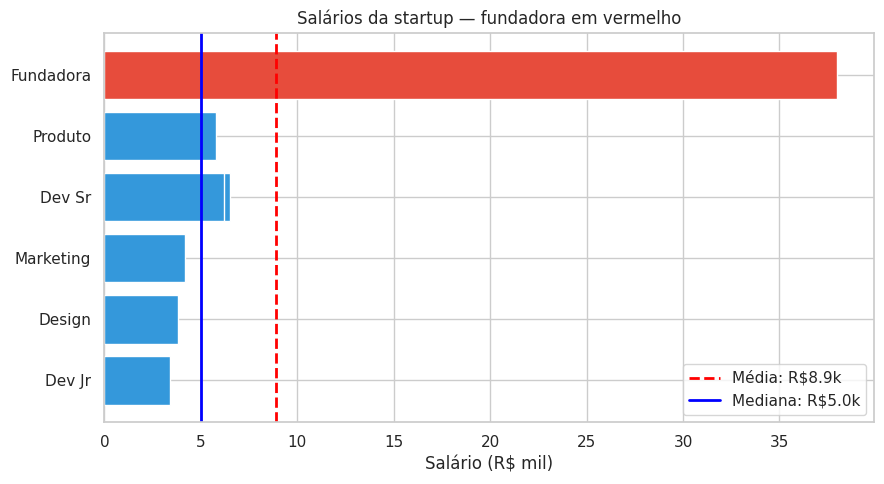

📌 Veja como a média (linha vermelha tracejada) está longe da maioria.
   A mediana (linha azul) fica muito mais próxima do que a equipe recebe.


In [ ]:
# ── Visualizando o impacto visualmente — dois gráficos separados ─────────────
#
# Quando temos poucos dados, um gráfico de barras simples é o mais claro.
# Vamos fazer dois gráficos: um com a fundadora e um sem.

# ── Gráfico 1: salários individuais com linhas de média e mediana ─────────────
plt.figure(figsize=(9, 5))

# Cores: vermelho para o outlier (fundadora), azul para o restante
cores = ['#e74c3c' if s == df_salarios['salario'].max() else '#3498db'
         for s in df_salarios['salario']]

# Gráfico de barras horizontais (.barh) — melhor quando os rótulos são longos
plt.barh(df_salarios['cargo'],       # eixo Y (vertical): os cargos
         df_salarios['salario']/1000, # eixo X (horizontal): salário em R$ mil
         color=cores,
         edgecolor='white')

# Linhas verticais mostrando onde cai a média e a mediana
plt.axvline(media_com/1000,   color='red',  linestyle='--', linewidth=2,
            label=f'Média: R${media_com/1000:.1f}k')
plt.axvline(mediana_com/1000, color='blue', linestyle='-',  linewidth=2,
            label=f'Mediana: R${mediana_com/1000:.1f}k')

plt.title('Salários da startup — fundadora em vermelho', fontsize=12)
plt.xlabel('Salário (R$ mil)')
plt.legend()
plt.tight_layout()
plt.show()

print('📌 Veja como a média (linha vermelha tracejada) está longe da maioria.')
print('   A mediana (linha azul) fica muito mais próxima do que a equipe recebe.')

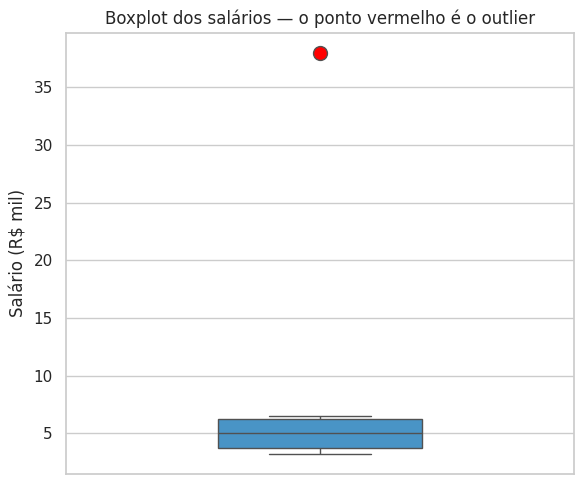

📦 Lendo o boxplot:
   — A CAIXA = 50% central dos dados (de Q1 a Q3)
   — A LINHA dentro da caixa = mediana
   — Os TRAÇOS que saem da caixa = valores normais (até 1,5× o IQR)
   — Os PONTOS fora = outliers


In [ ]:
# ── Boxplot: a forma mais direta de detectar outliers visualmente ─────────────
#
# O boxplot mostra 5 coisas de uma vez:
# 1. O mínimo  2. Q1 (25%)  3. Mediana  4. Q3 (75%)  5. O máximo
# E os pontos fora dos 'bigodes' são automaticamente marcados como outliers.

plt.figure(figsize=(6, 5))

# sns.boxplot() cria o boxplot — vert=True = caixa vertical
sns.boxplot(y=df_salarios['salario']/1000,  # y= define o eixo com os valores
            color='#3498db',                # cor da caixa
            width=0.4,                      # largura da caixa (0 a 1)
            flierprops={'marker':'o', 'markersize':10, 'markerfacecolor':'red'})
# flierprops controla como os outliers aparecem: círculo vermelho, tamanho 10

plt.title('Boxplot dos salários — o ponto vermelho é o outlier', fontsize=12)
plt.ylabel('Salário (R$ mil)')
plt.tight_layout()
plt.show()

print('📦 Lendo o boxplot:')
print('   — A CAIXA = 50% central dos dados (de Q1 a Q3)')
print('   — A LINHA dentro da caixa = mediana')
print('   — Os TRAÇOS que saem da caixa = valores normais (até 1,5× o IQR)')
print('   — Os PONTOS fora = outliers')

---
## 📐 Seção 4 — Variância e Desvio Padrão

A média nos diz **onde** os dados se concentram. O desvio padrão nos diz **o quanto** eles se afastam desse centro.

Dois grupos podem ter **a mesma média** e se comportar de formas completamente diferentes:
- Turma A: notas 6, 7, 7, 7, 8 → média 7, todos próximos
- Turma B: notas 2, 4, 7, 10, 12 → média 7, enorme variação

### As fórmulas:

$$\sigma^2 = \frac{\sum (x_i - \bar{x})^2}{n} \quad \text{(Variância)}$$

$$\sigma = \sqrt{\sigma^2} \quad \text{(Desvio Padrão)}$$

> **Por que usar o Desvio Padrão e não a Variância?**  
> A variância eleva ao quadrado — a unidade também fica ao quadrado (pontos², R$², metros²).
> O Desvio Padrão tira a raiz quadrada e volta à unidade original dos dados,
> tornando a interpretação direta.

In [ ]:
# ── Calculando passo a passo — notas da Julia ────────────────────────────────
#
# Vamos calcular manualmente para entender cada etapa.
# Depois confirmamos com pandas.

# Notas das 4 provas da Julia
notas = pd.Series([3, 5, 7, 9], name='notas')

# PASSO 0: calcular a média
media = notas.mean()
print(f'Notas: {notas.tolist()}')
print(f'Média: {media}')
print()

# PASSO 1: calcular o desvio de cada nota em relação à média
# Quanto cada nota está acima ou abaixo da média?
desvios = notas - media   # operação vetorizada: subtrai a média de CADA elemento
print(f'Desvios (nota - média): {desvios.tolist()}')
print('Nota: os negativos e positivos se cancelariam se somados — por isso precisamos do passo 2')
print()

# PASSO 2: elevar cada desvio ao quadrado
# O quadrado elimina os negativos e amplifica os desvios maiores
desvios_quad = desvios ** 2   # ** 2 = elevar ao quadrado cada elemento
print(f'Desvios ao quadrado: {desvios_quad.tolist()}')
print()

# PASSO 3: somar os quadrados e dividir por n → variância
variancia = desvios_quad.sum() / len(notas)
print(f'Variância σ² = {desvios_quad.sum()} ÷ {len(notas)} = {variancia:.2f}')
print(f'(unidade: pontos² — difícil de interpretar diretamente)')
print()

# PASSO 4: tirar a raiz quadrada → desvio padrão
# Isso 'volta' para a unidade original (pontos, não pontos²)
dp = variancia ** 0.5   # 0.5 = raiz quadrada (equivalente a np.sqrt)
print(f'Desvio Padrão σ = √{variancia:.2f} = {dp:.2f}')
print(f'(unidade: pontos — comparável às notas)',)
print()

# CONFERINDO com pandas
# ddof=0: divide por n (variância da população — usamos aqui para comparar)
# ddof=1: divide por n-1 (variância amostral — padrão no pandas)
dp_pandas = notas.std(ddof=0)
print(f'Confirmando com pandas (ddof=0): {dp_pandas:.2f} ✅')
print()
print(f'📌 Interpretação: as notas da Julia variam, em média, ±{dp:.2f} pontos em torno da média {media}.')

Notas: [3, 5, 7, 9]
Média: 6.0

Desvios (nota - média): [-3.0, -1.0, 1.0, 3.0]
Nota: os negativos e positivos se cancelariam se somados — por isso precisamos do passo 2

Desvios ao quadrado: [9.0, 1.0, 1.0, 9.0]

Variância σ² = 20.0 ÷ 4 = 5.00
(unidade: pontos² — difícil de interpretar diretamente)

Desvio Padrão σ = √5.00 = 2.24
(unidade: pontos — comparável às notas)

Confirmando com pandas (ddof=0): 2.24 ✅

📌 Interpretação: as notas da Julia variam, em média, ±2.24 pontos em torno da média 6.0.


Turma A → Média: 7.0  |  Desvio Padrão: 0.63
Turma B → Média: 7.0  |  Desvio Padrão: 3.69

Mesma média! Mas olhe o desvio padrão — muito diferente.


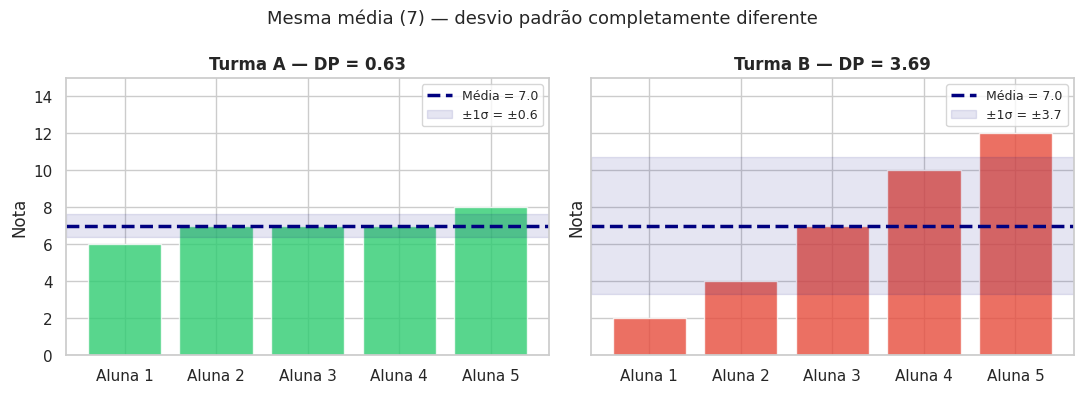

Turma A: DP = 0.63 → notas bem próximas da média (turma uniforme)
Turma B: DP = 3.69 → notas muito espalhadas (turma heterogênea)


In [ ]:
# ── Comparação visual: mesma média, dispersões bem diferentes ─────────────────
#
# Esse gráfico é o coração desta seção:
# mostra que a média sozinha não conta a história completa.

notas_A = pd.Series([6, 7, 7, 7, 8], name='Turma A')   # notas concentradas
notas_B = pd.Series([2, 4, 7, 10, 12], name='Turma B') # notas espalhadas

media_A = notas_A.mean()
media_B = notas_B.mean()
dp_A    = notas_A.std(ddof=0)
dp_B    = notas_B.std(ddof=0)

print(f'Turma A → Média: {media_A:.1f}  |  Desvio Padrão: {dp_A:.2f}')
print(f'Turma B → Média: {media_B:.1f}  |  Desvio Padrão: {dp_B:.2f}')
print()
print('Mesma média! Mas olhe o desvio padrão — muito diferente.')

# Dois gráficos lado a lado usando fig e axes
# plt.subplots(1, 2) cria 1 linha e 2 colunas de gráficos
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
# sharey=True faz ambos usarem a mesma escala no eixo Y — facilita a comparação

for ax, notas, cor, nome in [
    (ax_a, notas_A, '#2ecc71', 'Turma A'),
    (ax_b, notas_B, '#e74c3c', 'Turma B')
]:
    m  = notas.mean()
    dp = notas.std(ddof=0)
    nomes_alunos = [f'Aluna {i+1}' for i in range(len(notas))]

    ax.bar(nomes_alunos, notas, color=cor, alpha=0.8, edgecolor='white')

    # axhline: linha horizontal na média
    ax.axhline(m, color='navy', linestyle='--', linewidth=2.5,
               label=f'Média = {m:.1f}')

    # axhspan: faixa colorida mostrando o intervalo médio ± 1 desvio padrão
    ax.axhspan(m - dp, m + dp, alpha=0.1, color='navy',
               label=f'±1σ = ±{dp:.1f}')

    ax.set_title(f'{nome} — DP = {dp:.2f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nota')
    ax.set_ylim(0, 15)
    ax.legend(fontsize=9)

plt.suptitle('Mesma média (7) — desvio padrão completamente diferente', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Turma A: DP = {dp_A:.2f} → notas bem próximas da média (turma uniforme)')
print(f'Turma B: DP = {dp_B:.2f} → notas muito espalhadas (turma heterogênea)')

=== Comparando dois investimentos — 12 meses de retornos mensais ===

Tesouro Direto (%)
  Retorno médio:       0.83%
  Desvio Padrão:       0.01%  ← quanto o retorno oscila
  Coef. de Variação:   1%   ← risco relativo ao retorno

Ação de tech (%)
  Retorno médio:       1.75%
  Desvio Padrão:       4.40%  ← quanto o retorno oscila
  Coef. de Variação:   252%   ← risco relativo ao retorno



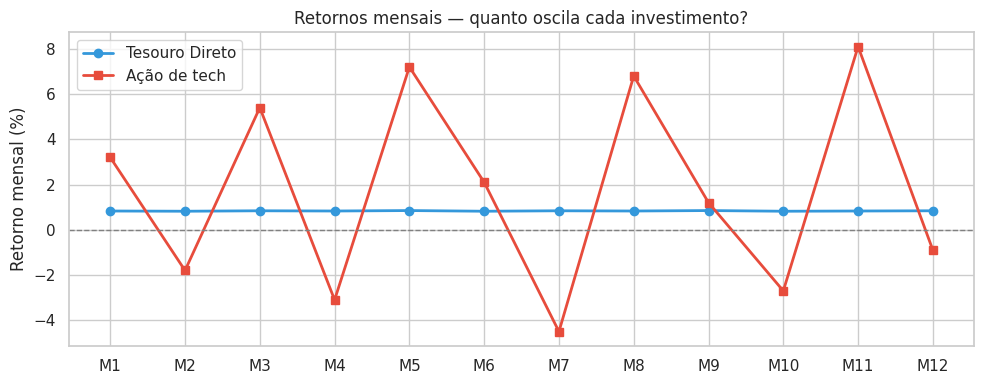

💡 Tesouro Direto: retorno pequeno mas estável (DP baixo = risco baixo).
   Ação de tech: retorno maior em média, mas meses negativos expressivos (DP alto = risco alto).


In [ ]:
# ── Desvio padrão na vida real: risco de investimento ────────────────────────
#
# Em finanças, o desvio padrão dos retornos É a medida de risco.
# Maior DP = mais oscilação = mais risco.

retornos = pd.DataFrame({
    'Tesouro Direto (%)': [0.83, 0.82, 0.84, 0.83, 0.85, 0.82, 0.84, 0.83, 0.85, 0.82, 0.83, 0.84],
    'Ação de tech (%)':   [3.2, -1.8, 5.4, -3.1, 7.2, 2.1, -4.5, 6.8, 1.2, -2.7, 8.1, -0.9]
})

print('=== Comparando dois investimentos — 12 meses de retornos mensais ===')
print()

for col in retornos.columns:
    m  = retornos[col].mean()            # retorno médio mensal
    dp = retornos[col].std()             # desvio padrão = volatilidade = risco
    cv = abs(dp / m) * 100               # Coeficiente de Variação = risco por unidade de retorno
    print(f'{col}')
    print(f'  Retorno médio:       {m:.2f}%')
    print(f'  Desvio Padrão:       {dp:.2f}%  ← quanto o retorno oscila')
    print(f'  Coef. de Variação:   {cv:.0f}%   ← risco relativo ao retorno')
    print()

# Visualizando os retornos mês a mês
meses = [f'M{i+1}' for i in range(12)]  # rótulos M1, M2, ..., M12

plt.figure(figsize=(10, 4))
plt.plot(meses, retornos['Tesouro Direto (%)'], marker='o', color='#3498db',
         linewidth=2, label='Tesouro Direto')
plt.plot(meses, retornos['Ação de tech (%)'],   marker='s', color='#e74c3c',
         linewidth=2, label='Ação de tech')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # linha do zero
plt.title('Retornos mensais — quanto oscila cada investimento?', fontsize=12)
plt.ylabel('Retorno mensal (%)')
plt.legend()
plt.tight_layout()
plt.show()

print('💡 Tesouro Direto: retorno pequeno mas estável (DP baixo = risco baixo).')
print('   Ação de tech: retorno maior em média, mas meses negativos expressivos (DP alto = risco alto).')

---
## 📈 Seção 5 — Visualizações Essenciais

**O gráfico certo para cada pergunta:**

| Pergunta | Gráfico | Erro comum |
|----------|---------|------------|
| Qual categoria tem mais? | **Barras** | Usar pizza com muitas fatias |
| Como evoluiu no tempo? | **Linhas** | Usar barras para tendência temporal |
| Qual % cada parte representa? | **Pizza** | Usar com mais de 6 categorias |
| Como os valores se distribuem? | **Histograma** | Confundir com gráfico de barras |
| Existe relação entre X e Y? | **Dispersão** | Concluir causalidade só por correlação |
| Como comparar grupos? | **Boxplot** | Só mostrar a média de cada grupo |

> 🔍 **Antes de qualquer gráfico, leia:** título → eixo X → eixo Y →
> **escala** (começa no zero?) → legenda → fonte.

In [ ]:
# ── Preparando os dados que vamos usar nos próximos exemplos ─────────────────

# Dados de uma loja de cosméticos — 6 meses de 2024
df_vendas = pd.DataFrame({
    'mes':      ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'],
    'receita':  [12400, 10800, 15200, 14100, 17800, 19500],  # em R$
    'unidades': [310,   275,   390,   358,   445,   490]     # produtos vendidos
})

# Participação por linha de produto (% das vendas totais)
df_produtos = pd.DataFrame({
    'produto':   ['Hidratante', 'Sérum', 'Protetor', 'Esfoliante', 'Outros'],
    'percent':   [38,           22,      18,          12,           10]
})

print('Dados de vendas:')
print(df_vendas)

Dados de vendas:
   mes  receita  unidades
0  Jan    12400       310
1  Fev    10800       275
2  Mar    15200       390
3  Abr    14100       358
4  Mai    17800       445
5  Jun    19500       490


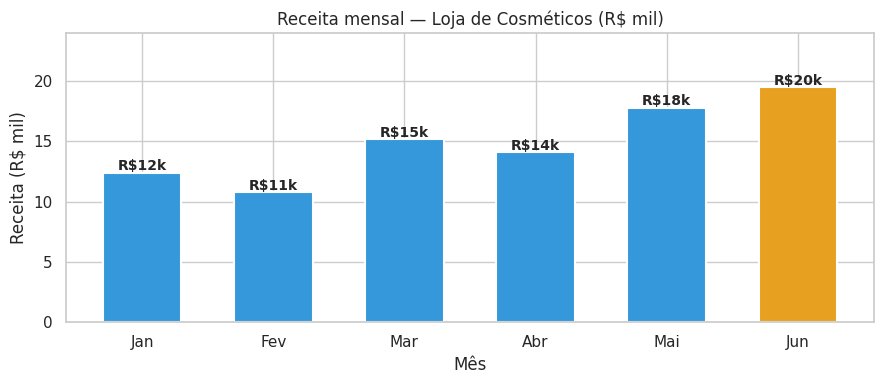

📊 Regra: o eixo Y SEMPRE deve começar em zero em gráficos de barras.
   Começar em outro valor distorce visualmente as diferenças.


In [ ]:
# ── GRÁFICO 1: Barras — 'qual mês vendeu mais?' ───────────────────────────────
#
# Use barras quando quiser COMPARAR valores entre CATEGORIAS DISTINTAS.
# Cada barra é uma categoria independente (cada mês).

plt.figure(figsize=(9, 4))

# Definindo cores: dourado para o maior valor, azul para os demais
receita_max = df_vendas['receita'].max()   # encontra o maior valor
cores_meses = ['#e8a020' if r == receita_max else '#3498db'
               for r in df_vendas['receita']]

# plt.bar() cria o gráfico de barras
barras = plt.bar(df_vendas['mes'],         # eixo X: os meses
                 df_vendas['receita']/1000, # eixo Y: receita em R$ mil
                 color=cores_meses,
                 edgecolor='white',
                 linewidth=1.5,
                 width=0.6)               # width: largura das barras (0 a 1)

# Adicionando o valor em cima de cada barra
for barra in barras:
    altura = barra.get_height()           # pega a altura da barra
    plt.text(
        barra.get_x() + barra.get_width()/2,  # posição X: centro da barra
        altura + 0.2,                          # posição Y: um pouco acima da barra
        f'R${altura:.0f}k',                    # texto a exibir
        ha='center',                           # alinhamento horizontal: centrado
        fontsize=10,
        fontweight='bold')

plt.title('Receita mensal — Loja de Cosméticos (R$ mil)', fontsize=12)
plt.xlabel('Mês')
plt.ylabel('Receita (R$ mil)')
plt.ylim(0, 24)  # limite do eixo Y: começa em 0!
plt.tight_layout()
plt.show()

print('📊 Regra: o eixo Y SEMPRE deve começar em zero em gráficos de barras.')
print('   Começar em outro valor distorce visualmente as diferenças.')

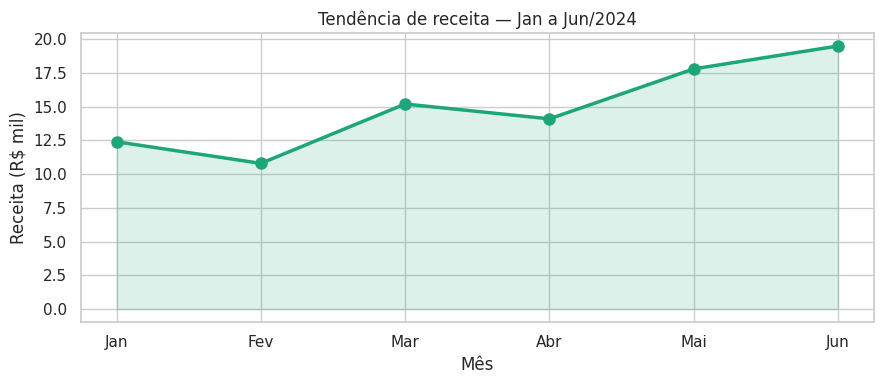

📈 A linha conecta os pontos e torna a tendência de crescimento imediata.
   Use LINHAS para tempo. Use BARRAS para categorias.


In [ ]:
# ── GRÁFICO 2: Linhas — 'como a receita evoluiu ao longo do tempo?' ──────────
#
# Use linhas quando quiser mostrar TENDÊNCIA ou EVOLUÇÃO no tempo.
# A inclinação da linha comunica velocidade de mudança.

plt.figure(figsize=(9, 4))

# plt.plot() cria o gráfico de linhas
plt.plot(df_vendas['mes'],         # eixo X: os meses (sequência temporal)
         df_vendas['receita']/1000, # eixo Y: receita em R$ mil
         color='#1da67a',           # cor da linha
         linewidth=2.5,             # espessura da linha
         marker='o',                # 'o' = círculo em cada ponto de dado
         markersize=8)              # tamanho dos círculos

# fill_between preenche a área entre a linha e o eixo X
# Cria o efeito de 'gráfico de área' que enfatiza o volume
plt.fill_between(df_vendas['mes'],
                 df_vendas['receita']/1000,
                 alpha=0.15,        # alpha = transparência (0=invisível, 1=opaco)
                 color='#1da67a')

plt.title('Tendência de receita — Jan a Jun/2024', fontsize=12)
plt.xlabel('Mês')
plt.ylabel('Receita (R$ mil)')
plt.tight_layout()
plt.show()

print('📈 A linha conecta os pontos e torna a tendência de crescimento imediata.')
print('   Use LINHAS para tempo. Use BARRAS para categorias.')

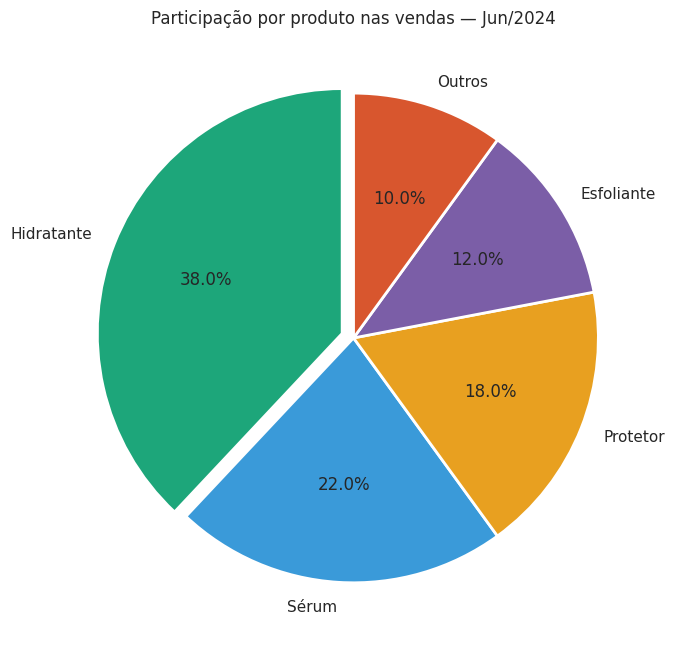

🥧 Hidratante responde por 38% das vendas — quase 2× o segundo colocado.


In [ ]:
# ── GRÁFICO 3: Pizza — 'qual % cada produto representa nas vendas?' ───────────
#
# Use pizza para mostrar PROPORÇÃO (partes de um todo = 100%).
# Funciona bem com até 5-6 fatias. Com mais, fica ilegível.
# EVITE pizza 3D: a perspectiva distorce visualmente as fatias.

plt.figure(figsize=(7, 7))  # quadrado — pizza fica melhor assim

# explode: quanto cada fatia 'sai' do centro
# Vamos destacar a maior fatia (índice 0 = Hidratante)
explode = [0.05, 0, 0, 0, 0]  # só a primeira fatia se afasta um pouco

plt.pie(
    df_produtos['percent'],           # os valores (devem somar 100%)
    labels=df_produtos['produto'],    # rótulo de cada fatia
    autopct='%1.1f%%',                # '%1.1f%%' exibe '38.0%' dentro de cada fatia
    startangle=90,                    # começa das 12h (mais natural de ler)
    explode=explode,                  # destaca a maior fatia
    colors=['#1da67a','#3a9ad9','#e8a020','#7b5ea7','#d8562e'],
    wedgeprops={'edgecolor':'white', 'linewidth':2}  # bordas brancas entre fatias
)

plt.title('Participação por produto nas vendas — Jun/2024', fontsize=12)
plt.tight_layout()
plt.show()

print('🥧 Hidratante responde por 38% das vendas — quase 2× o segundo colocado.')

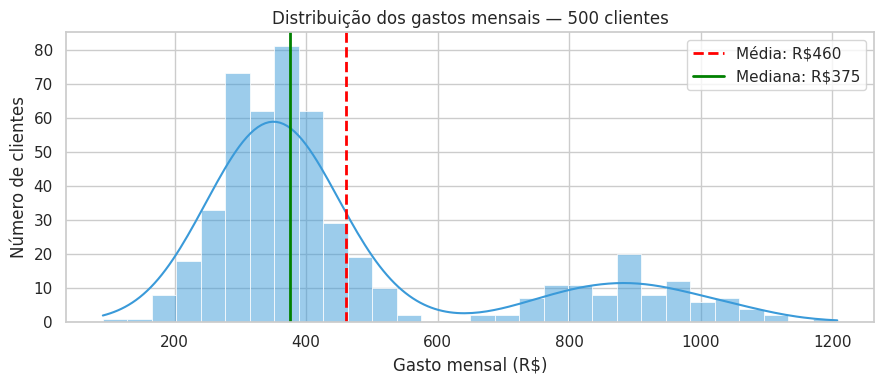

📦 Dois picos = dois grupos (bimodal): clientes regulares e premium.
   A média (R$460) foi puxada para cima pelo grupo premium.
   A mediana (R$375) representa melhor o cliente mais comum.


In [ ]:
# ── GRÁFICO 4: Histograma — 'como os gastos se distribuem?' ───────────────────
#
# O histograma agrupa valores em FAIXAS e mostra quantos caem em cada faixa.
# DIFERENÇA das barras normais: as colunas ficam GRUDADAS (sem espaço)
# porque representam faixas contínuas, não categorias separadas.

# Gerando dados de gastos mensais de 500 clientes
# np.concatenate junta dois arrays em um só
gastos_500 = np.concatenate([
    np.random.normal(350, 80, 400),    # 400 clientes: gasto médio R$350
    np.random.normal(900, 100, 100),   # 100 clientes premium: gasto médio R$900
])

media_g   = gastos_500.mean()
mediana_g = np.median(gastos_500)  # np.median funciona diretamente com arrays numpy

plt.figure(figsize=(9, 4))

# sns.histplot() é o histograma do seaborn
# kde=True adiciona a curva de densidade suavizada (linha por cima das barras)
sns.histplot(gastos_500,
             bins=30,         # quantidade de faixas (colunas)
             kde=True,        # adiciona curva de densidade (KDE)
             color='#3a9ad9', # cor das barras
             edgecolor='white',
             linewidth=0.5)

# axvline: linha vertical — marcando onde ficam a média e a mediana
plt.axvline(media_g,   color='red',   linestyle='--', linewidth=2,
            label=f'Média: R${media_g:.0f}')
plt.axvline(mediana_g, color='green', linestyle='-',  linewidth=2,
            label=f'Mediana: R${mediana_g:.0f}')

plt.title('Distribuição dos gastos mensais — 500 clientes', fontsize=12)
plt.xlabel('Gasto mensal (R$)')
plt.ylabel('Número de clientes')
plt.legend()
plt.tight_layout()
plt.show()

print('📦 Dois picos = dois grupos (bimodal): clientes regulares e premium.')
print(f'   A média (R${media_g:.0f}) foi puxada para cima pelo grupo premium.')
print(f'   A mediana (R${mediana_g:.0f}) representa melhor o cliente mais comum.')

/tmp/ipykernel_4740/863148537.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dept,         # o DataFrame com os dados


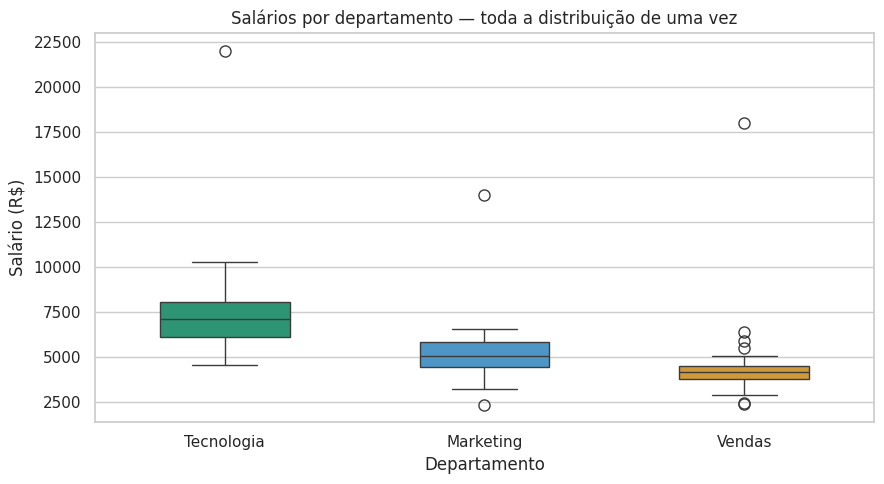

📦 O que cada parte do boxplot mostra:
   Linha no meio da caixa = mediana
   Base da caixa = Q1 (25% dos dados estão abaixo)
   Topo da caixa = Q3 (75% dos dados estão abaixo)
   Traços que saem = valores normais
   Pontos isolados = outliers (lideranças com salários atípicos)


In [ ]:
# ── GRÁFICO 5: Boxplot — 'como comparar grupos lado a lado?' ─────────────────
#
# O boxplot mostra a distribuição completa de um grupo em uma caixa compacta.
# É ideal para comparar vários grupos de uma vez.

# Criando dados de salários por departamento
np.random.seed(42)
df_dept = pd.DataFrame({
    'departamento': ['Tecnologia']*40 + ['Marketing']*35 + ['Vendas']*40,
    'salario': np.concatenate([
        np.random.normal(7500, 1500, 40),   # Tecnologia: média R$7.500
        np.random.normal(5000, 1000, 35),   # Marketing:  média R$5.000
        np.random.normal(4200,  900, 40),   # Vendas:     média R$4.200
    ])
})

# Adicionando lideranças com salários altos (serão os outliers)
extras = pd.DataFrame({
    'departamento': ['Tecnologia', 'Marketing', 'Vendas'],
    'salario':      [22000,         14000,        18000]
})
df_dept = pd.concat([df_dept, extras], ignore_index=True)
# pd.concat junta dois DataFrames — ignore_index=True reinicia o índice

plt.figure(figsize=(9, 5))

sns.boxplot(data=df_dept,         # o DataFrame com os dados
            x='departamento',     # eixo X: os grupos a comparar
            y='salario',          # eixo Y: os valores
            palette=['#1da67a','#3a9ad9','#e8a020'],  # cores dos grupos
            width=0.5,
            flierprops={'marker':'o', 'markersize':8})
# flierprops: aparência dos outliers (pontos fora dos bigodes)

plt.title('Salários por departamento — toda a distribuição de uma vez', fontsize=12)
plt.xlabel('Departamento')
plt.ylabel('Salário (R$)')
plt.tight_layout()
plt.show()

print('📦 O que cada parte do boxplot mostra:')
print('   Linha no meio da caixa = mediana')
print('   Base da caixa = Q1 (25% dos dados estão abaixo)')
print('   Topo da caixa = Q3 (75% dos dados estão abaixo)')
print('   Traços que saem = valores normais')
print('   Pontos isolados = outliers (lideranças com salários atípicos)')

---
## 🔔 Seção 6 — Distribuições Estatísticas

Uma **distribuição** descreve o perfil dos dados:
onde a maioria se concentra, quão longe chegam os extremos, e se a curva é simétrica ou não.

| Distribuição | Formato | Quando usar |
|-------------|---------|-------------|
| **Normal** | Sino simétrico | Alturas, notas, erros de medição |
| **Assimétrica** | Cauda mais longa de um lado | Renda, preços de imóveis |
| **Binomial** | Discreta, dois resultados possíveis | Sucesso/falha em n tentativas |
| **Poisson** | Discreta, eventos raros | Chamadas/hora, falhas/dia |

> **Regra prática:** se a distribuição é assimétrica — para qualquer lado —
> prefira a **mediana** à média.

=== Regra 68-95-99,7 verificada nos dados ===
Dentro de ±1σ (155–169 cm): 69.3%  (teórico: 68%)
Dentro de ±2σ (148–176 cm): 95.5%  (teórico: 95%)
Dentro de ±3σ (141–183 cm): 99.7%  (teórico: 99.7%)


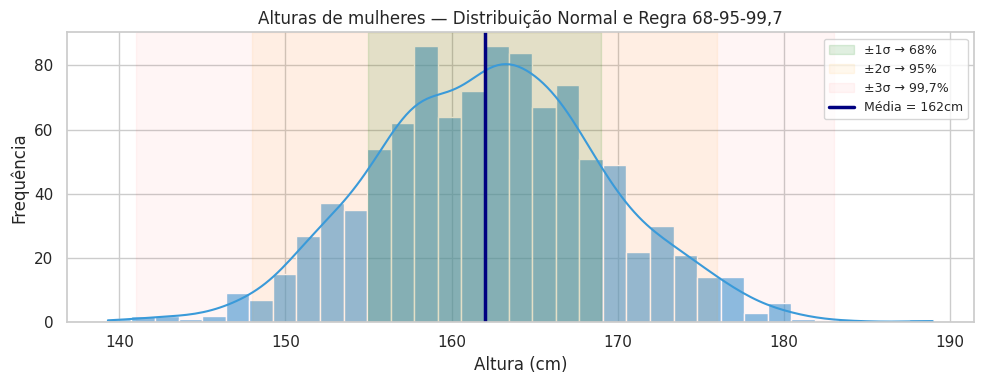

In [ ]:
# ── Distribuição Normal — a curva sino ───────────────────────────────────────
#
# A Normal é a mais importante da estatística.
# Ela aparece em: alturas, pesos, notas, erros de medição, pressão arterial...
#
# Características:
# • Simétrica: metade dos dados abaixo da média, metade acima
# • Média = Mediana = Moda (todos no centro)
# • Regra 68-95-99,7: proporção de dados dentro de 1, 2 e 3 desvios padrões

# Simulando alturas de 1.000 mulheres brasileiras
# Parâmetros aproximados reais: média 162cm, desvio padrão 7cm
mu    = 162  # média (center da curva)
sigma = 7    # desvio padrão (largura da curva)

alturas = pd.Series(np.random.normal(mu, sigma, 1000), name='altura_cm')

# Verificando a regra 68-95-99,7 nos dados gerados
# .mean() retorna a proporção de Trues quando usada em condições booleanas
pct_1sigma = ((alturas >= mu-sigma)   & (alturas <= mu+sigma))  .mean() * 100
pct_2sigma = ((alturas >= mu-2*sigma) & (alturas <= mu+2*sigma)).mean() * 100
pct_3sigma = ((alturas >= mu-3*sigma) & (alturas <= mu+3*sigma)).mean() * 100

print('=== Regra 68-95-99,7 verificada nos dados ===')
print(f'Dentro de ±1σ ({mu-sigma}–{mu+sigma} cm): {pct_1sigma:.1f}%  (teórico: 68%)')
print(f'Dentro de ±2σ ({mu-2*sigma}–{mu+2*sigma} cm): {pct_2sigma:.1f}%  (teórico: 95%)')
print(f'Dentro de ±3σ ({mu-3*sigma}–{mu+3*sigma} cm): {pct_3sigma:.1f}%  (teórico: 99.7%)')

# Visualizando o histograma com as faixas da regra empírica
plt.figure(figsize=(10, 4))

# Histograma + KDE das alturas
sns.histplot(alturas, bins=35, kde=True, color='#3a9ad9', alpha=0.6, edgecolor='white')

# Faixas coloridas: cada uma representa uma faixa da regra empírica
# axvspan preenche uma faixa vertical com cor
plt.axvspan(mu-1*sigma, mu+1*sigma, alpha=0.12, color='green',  label=f'±1σ → 68%')
plt.axvspan(mu-2*sigma, mu+2*sigma, alpha=0.07, color='orange', label=f'±2σ → 95%')
plt.axvspan(mu-3*sigma, mu+3*sigma, alpha=0.04, color='red',    label=f'±3σ → 99,7%')

# Linha vertical na média
plt.axvline(mu, color='navy', linewidth=2.5, label=f'Média = {mu}cm')

plt.title('Alturas de mulheres — Distribuição Normal e Regra 68-95-99,7', fontsize=12)
plt.xlabel('Altura (cm)')
plt.ylabel('Frequência')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

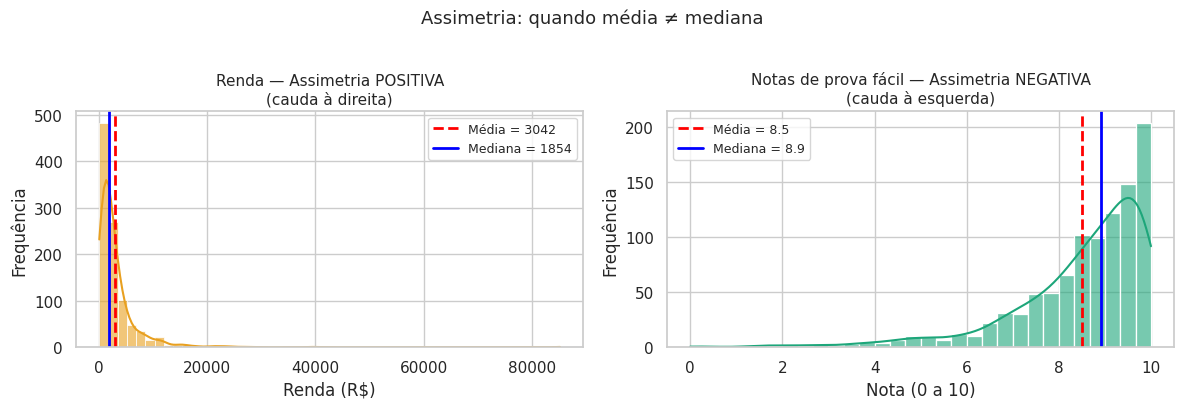

💡 Quando há assimetria, a média é puxada na direção da cauda.
   A mediana fica mais estável. Por isso o IBGE usa mediana de renda.


In [ ]:
# ── Assimetria: quando os dados não são simétricos ────────────────────────────
#
# A assimetria indica se a 'cauda' dos dados é mais longa de um lado.
#
# ASSIMETRIA POSITIVA: cauda longa à DIREITA → Média > Mediana
#   Exemplo: renda. Muita gente ganha pouco, algumas poucas ganham muito.
#
# ASSIMETRIA NEGATIVA: cauda longa à ESQUERDA → Média < Mediana
#   Exemplo: nota de prova muito fácil. Maioria tira alto, algumas poucas tiram baixo.
#
# REGRA: se a distribuição for assimétrica → prefira a MEDIANA

np.random.seed(42)

# Simulando renda (assimetria positiva) com distribuição log-normal
renda = pd.Series(np.random.lognormal(mean=7.5, sigma=1.0, size=1000))

# Simulando notas de prova fácil (assimetria negativa)
notas_faceis = pd.Series(10 - np.random.exponential(scale=1.5, size=1000)).clip(0, 10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: renda (assimetria positiva)
sns.histplot(renda, bins=50, kde=True, color='#e8a020', alpha=0.6,
             edgecolor='white', ax=ax1)
ax1.axvline(renda.mean(),   color='red',  linestyle='--', linewidth=2,
            label=f'Média = {renda.mean():.0f}')
ax1.axvline(renda.median(), color='blue', linestyle='-',  linewidth=2,
            label=f'Mediana = {renda.median():.0f}')
ax1.set_title('Renda — Assimetria POSITIVA\n(cauda à direita)', fontsize=11)
ax1.set_xlabel('Renda (R$)')
ax1.set_ylabel('Frequência')
ax1.legend(fontsize=9)

# Gráfico 2: notas fáceis (assimetria negativa)
sns.histplot(notas_faceis, bins=30, kde=True, color='#1da67a', alpha=0.6,
             edgecolor='white', ax=ax2)
ax2.axvline(notas_faceis.mean(),   color='red',  linestyle='--', linewidth=2,
            label=f'Média = {notas_faceis.mean():.1f}')
ax2.axvline(notas_faceis.median(), color='blue', linestyle='-',  linewidth=2,
            label=f'Mediana = {notas_faceis.median():.1f}')
ax2.set_title('Notas de prova fácil — Assimetria NEGATIVA\n(cauda à esquerda)', fontsize=11)
ax2.set_xlabel('Nota (0 a 10)')
ax2.set_ylabel('Frequência')
ax2.legend(fontsize=9)

plt.suptitle('Assimetria: quando média ≠ mediana', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('💡 Quando há assimetria, a média é puxada na direção da cauda.')
print('   A mediana fica mais estável. Por isso o IBGE usa mediana de renda.')

=== Distribuição Binomial: conversões no app fintech ===
n = 20 usuários | p = 0.08 (8% de conversão)

Probabilidade de cada resultado:
  P(exatamente 0 conversões) = 18.87%
  P(exatamente 1 conversões) = 32.82%
  P(exatamente 2 conversões) = 27.11%
  P(exatamente 3 conversões) = 14.14%
  P(exatamente 4 conversões) = 5.23%
  P(exatamente 5 conversões) = 1.45%
  P(exatamente 6 conversões) = 0.32%
  P(exatamente 7 conversões) = 0.05%

P(até 3 conversões):  92.9%
P(5 ou mais):         1.8%


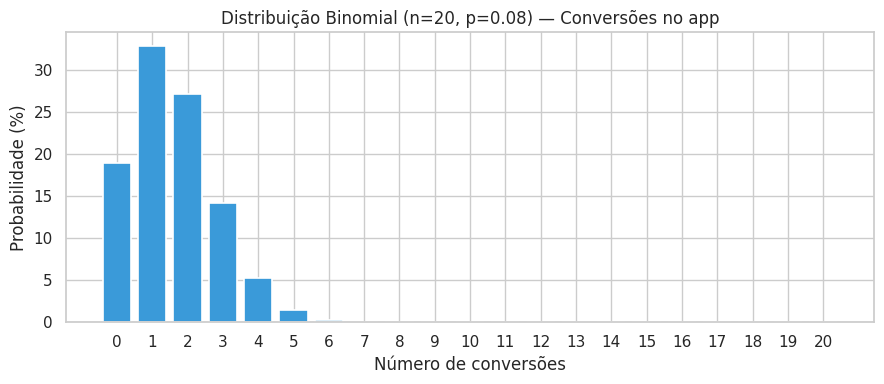

In [ ]:
# ── Distribuição Binomial: sucesso/falha em n tentativas ─────────────────────
#
# Use a Binomial quando:
# ✓ O número de tentativas é FIXO (você sabe quantas são)
# ✓ Cada tentativa tem só 2 resultados: sucesso ou fracasso
# ✓ A probabilidade de sucesso é IGUAL em todas as tentativas
#
# Parâmetros: n = número de tentativas, p = probabilidade de sucesso

from scipy.stats import binom   # importa a distribuição binomial do scipy

# Cenário: taxa de conversão de um app fintech = 8%
# Você aborda 20 novos usuários. Quantos devem converter?
n = 20    # número de usuários abordados
p = 0.08  # 8% de probabilidade de cada usuário converter

# Calculando probabilidades
print('=== Distribuição Binomial: conversões no app fintech ===')
print(f'n = {n} usuários | p = {p} ({p*100:.0f}% de conversão)')
print()
print('Probabilidade de cada resultado:')
for k in range(8):  # mostrando de 0 a 7 conversões
    # binom.pmf(k, n, p) = P(exatamente k sucessos em n tentativas com prob. p)
    prob = binom.pmf(k, n, p) * 100
    print(f'  P(exatamente {k} conversões) = {prob:.2f}%')
print()

# binom.cdf(k, n, p) = P(até k sucessos) — probabilidade acumulada
print(f'P(até 3 conversões):  {binom.cdf(3, n, p)*100:.1f}%')

# P(5 ou mais) = 1 - P(até 4)
print(f'P(5 ou mais):         {(1 - binom.cdf(4, n, p))*100:.1f}%')

# Visualizando a distribuição inteira
k_todos = np.arange(0, n+1)             # todos os resultados possíveis: 0, 1, 2, ..., 20
probs_todos = binom.pmf(k_todos, n, p)  # probabilidade de cada resultado

plt.figure(figsize=(9, 4))
plt.bar(k_todos, probs_todos * 100,
        color='#3a9ad9', edgecolor='white', linewidth=1.2)
plt.title(f'Distribuição Binomial (n={n}, p={p}) — Conversões no app', fontsize=12)
plt.xlabel('Número de conversões')
plt.ylabel('Probabilidade (%)')
plt.xticks(k_todos)   # marca cada número no eixo X
plt.tight_layout()
plt.show()

=== Distribuição de Poisson: chamadas em call center ===
Taxa média: λ = 5 chamadas/hora

Probabilidades para a próxima hora:
  P(exatamente  0 chamadas): 0.67%
  P(exatamente  2 chamadas): 8.42%
  P(exatamente  5 chamadas): 17.55%
  P(exatamente  8 chamadas): 6.53%
  P(exatamente 10 chamadas): 1.81%

P(mais de 8 chamadas): 6.8%


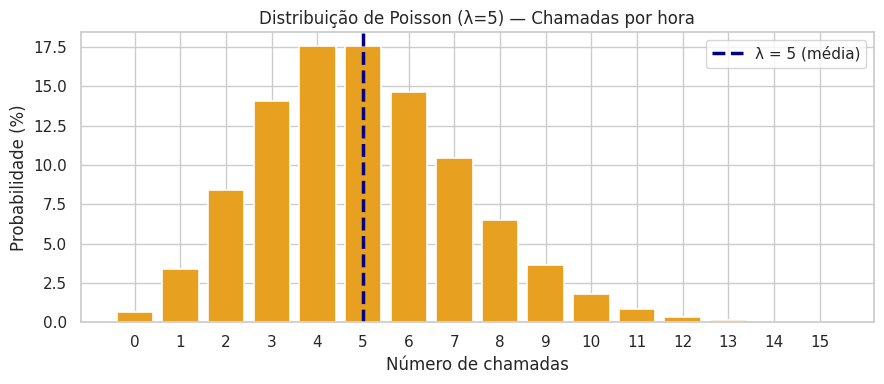

💡 O pico está em k=4 e k=5 — os valores mais prováveis são próximos de λ.


In [ ]:
# ── Distribuição de Poisson: eventos raros num intervalo de tempo ─────────────
#
# Use Poisson quando:
# ✓ Você NÃO sabe quantas tentativas têm (diferente da Binomial)
# ✓ Você sabe apenas a TAXA MÉDIA de eventos por intervalo (λ = lambda)
# ✓ Os eventos são independentes entre si
#
# Exemplos: chamadas por hora, pedidos por dia, bugs por sprint

from scipy.stats import poisson   # importa a distribuição de Poisson

# Cenário: central de atendimento recebe em média 5 chamadas/hora
lam = 5   # lambda = taxa média de 5 chamadas por hora

print('=== Distribuição de Poisson: chamadas em call center ===')
print(f'Taxa média: λ = {lam} chamadas/hora')
print()
print('Probabilidades para a próxima hora:')
for k in [0, 2, 5, 8, 10]:
    # poisson.pmf(k, lambda) = P(exatamente k eventos)
    print(f'  P(exatamente {k:2d} chamadas): {poisson.pmf(k, lam)*100:.2f}%')
print()
print(f'P(mais de 8 chamadas): {(1-poisson.cdf(8, lam))*100:.1f}%')

# Visualizando
k_vals = np.arange(0, 16)               # 0 a 15 chamadas
probs_p = poisson.pmf(k_vals, lam)      # probabilidade de cada valor

plt.figure(figsize=(9, 4))
plt.bar(k_vals, probs_p * 100,
        color='#e8a020', edgecolor='white', linewidth=1.2)
plt.axvline(lam, color='navy', linestyle='--', linewidth=2.5,
            label=f'λ = {lam} (média)')
plt.title(f'Distribuição de Poisson (λ={lam}) — Chamadas por hora', fontsize=12)
plt.xlabel('Número de chamadas')
plt.ylabel('Probabilidade (%)')
plt.xticks(k_vals)
plt.legend()
plt.tight_layout()
plt.show()

print('💡 O pico está em k=4 e k=5 — os valores mais prováveis são próximos de λ.')

=== Análise de aluguéis de um bairro ===
Q1  (25%):  R$ 1,989  → 25% dos imóveis custam menos que isso
Q2  (50%):  R$ 2,274  → metade acima, metade abaixo (mediana)
Q3  (75%):  R$ 2,713  → 75% dos imóveis custam menos que isso
IQR:        R$ 724  → largura dos 50% centrais
Limite sup: R$ 3,798  → acima disso = outlier
Outliers:   [4257.451919132043, 4289.384071836795, 4341.071938869888, 4344.518934517906, 4349.472886924639, 4382.367554060353, 4401.70135602067, 4434.098433648746, 4529.123264804412, 4598.6253328979055, 4607.133771453524, 4653.980229934007, 4774.620635310623, 4790.593497159867, 4943.368213422455, 8000.0, 11000.0, 14000.0] (coberturas de luxo)


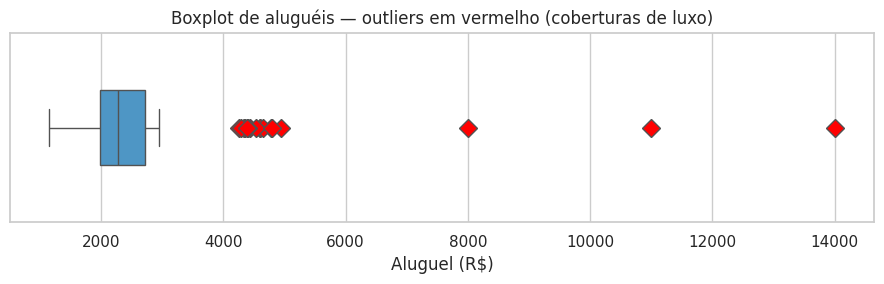

In [ ]:
# ── Quartis, IQR e Boxplot — localizando valores na distribuição ──────────────
#
# Quartis dividem os dados ordenados em 4 partes iguais (25% cada):
# Q1 = 25% dos dados estão ABAIXO deste valor
# Q2 = 50% dos dados estão abaixo = MEDIANA
# Q3 = 75% dos dados estão abaixo
# IQR = Q3 - Q1 = largura dos 50% centrais
#
# Critério de outlier (Tukey):
# Outlier se valor < Q1 - 1.5×IQR  ou  valor > Q3 + 1.5×IQR

np.random.seed(42)
# Dados de aluguéis de um bairro (com algumas coberturas de luxo como outliers)
alugueis = pd.Series(np.concatenate([
    np.random.normal(2200, 400, 80),   # apartamentos comuns
    np.random.normal(4500, 300, 15),   # apartamentos maiores
    [8000, 11000, 14000]               # coberturas de luxo (outliers)
]))

# Calculando os quartis com pandas
q1  = alugueis.quantile(0.25)   # 25° percentil
q2  = alugueis.median()         # 50° percentil = mediana
q3  = alugueis.quantile(0.75)   # 75° percentil
iqr = q3 - q1                   # Amplitude InterQuartil

lim_sup  = q3 + 1.5 * iqr       # limite acima do qual é considerado outlier
outliers = alugueis[alugueis > lim_sup]  # filtra apenas os outliers

print('=== Análise de aluguéis de um bairro ===')
print(f'Q1  (25%):  R$ {q1:,.0f}  → 25% dos imóveis custam menos que isso')
print(f'Q2  (50%):  R$ {q2:,.0f}  → metade acima, metade abaixo (mediana)')
print(f'Q3  (75%):  R$ {q3:,.0f}  → 75% dos imóveis custam menos que isso')
print(f'IQR:        R$ {iqr:,.0f}  → largura dos 50% centrais')
print(f'Limite sup: R$ {lim_sup:,.0f}  → acima disso = outlier')
print(f'Outliers:   {sorted(outliers.tolist())} (coberturas de luxo)')

# Boxplot horizontal para visualizar
plt.figure(figsize=(9, 3))
sns.boxplot(x=alugueis,
            color='#3a9ad9',
            width=0.4,
            flierprops={'marker':'D', 'markerfacecolor':'red', 'markersize':9})
# 'D' = losango vermelho para os outliers

plt.title('Boxplot de aluguéis — outliers em vermelho (coberturas de luxo)', fontsize=12)
plt.xlabel('Aluguel (R$)')
plt.tight_layout()
plt.show()

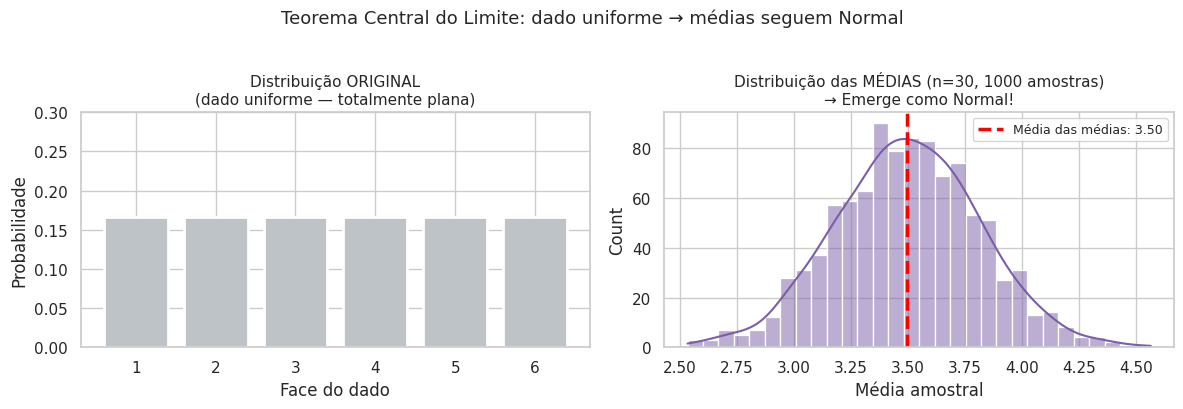

🤯 Mesmo começando com uma distribuição totalmente plana (uniforme),
   as médias das amostras formam uma distribuição Normal.
   Isso é o TCL: o que torna possível pesquisas com 1.000 pessoas representando 200 milhões.


In [ ]:
# ── Teorema Central do Limite (TCL) ───────────────────────────────────────────
#
# Um dos resultados mais poderosos da estatística:
# Se você tirar MUITAS amostras de QUALQUER distribuição,
# a distribuição das MÉDIAS dessas amostras vai se parecer com uma Normal.
#
# Condição: amostras com n ≥ 30
# Por que importa: justifica usar a Normal em testes estatísticos
#                 mesmo quando os dados originais não são normais.

# Demonstração com um dado: distribuição UNIFORME (o oposto da Normal)
faces_do_dado = np.array([1, 2, 3, 4, 5, 6])  # cada face com igual probabilidade

n_amostras  = 1000  # vamos tirar 1.000 amostras
tam_amostra = 30    # cada amostra tem 30 lançamentos

# Para cada amostra, sorteamos 30 lançamentos e calculamos a média
medias_amostrais = []   # lista vazia para guardar as médias
for _ in range(n_amostras):   # repetimos n_amostras vezes
    # np.random.choice sorteia valores aleatórios da lista, com reposição
    amostra = np.random.choice(faces_do_dado, size=tam_amostra, replace=True)
    medias_amostrais.append(amostra.mean())   # calcula e guarda a média
medias_amostrais = pd.Series(medias_amostrais)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: distribuição original do dado (plana/uniforme)
ax1.bar(faces_do_dado, [1/6]*6, color='#bdc3c7', edgecolor='white', linewidth=2, width=0.8)
ax1.set_title('Distribuição ORIGINAL\n(dado uniforme — totalmente plana)', fontsize=11)
ax1.set_xlabel('Face do dado')
ax1.set_ylabel('Probabilidade')
ax1.set_ylim(0, 0.3)

# Gráfico 2: distribuição das médias (deve emergir como Normal — TCL!)
sns.histplot(medias_amostrais, bins=30, kde=True, color='#7b5ea7',
             edgecolor='white', ax=ax2)
ax2.axvline(medias_amostrais.mean(), color='red', linewidth=2.5, linestyle='--',
            label=f'Média das médias: {medias_amostrais.mean():.2f}')
ax2.set_title(f'Distribuição das MÉDIAS (n={tam_amostra}, {n_amostras} amostras)\n→ Emerge como Normal!',
              fontsize=11)
ax2.set_xlabel('Média amostral')
ax2.legend(fontsize=9)

plt.suptitle('Teorema Central do Limite: dado uniforme → médias seguem Normal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('🤯 Mesmo começando com uma distribuição totalmente plana (uniforme),')
print('   as médias das amostras formam uma distribuição Normal.')
print('   Isso é o TCL: o que torna possível pesquisas com 1.000 pessoas representando 200 milhões.')

---
## 🔗 Seção 7 — Correlação e Causalidade

**Correlação** mede a força e a direção da relação entre duas variáveis numéricas.
O coeficiente vai de **−1 a +1**:

| Valor | O que significa | Exemplo |
|-------|----------------|---------|
| +1,00 | Positiva perfeita: X sobe, Y sobe na mesma proporção | km × litros de combustível |
| +0,70 | Positiva forte: tendem a subir juntas | horas de estudo × nota |
| ≈ 0   | Sem relação linear | tamanho do pé × QI |
| −0,70 | Negativa forte: quando X sobe, Y cai | preço × demanda |
| −1,00 | Negativa perfeita: X sobe, Y cai na mesma proporção | — |

**Dois coeficientes principais:**
- **Pearson (r):** mede correlação **linear**. Sensível a outliers.
- **Spearman (ρ):** mede correlação usando **rankings**. Mais robusto a outliers.

---
> ### ⚠️ Correlação ≠ Causalidade!
> Duas variáveis podem se mover juntas sem que uma cause a outra.
> Sorvete e afogamentos têm alta correlação no verão — mas sorvete não causa afogamento.
> A **temperatura** (variável confundidora) aumenta os dois ao mesmo tempo.

=== Correlação de Pearson: horas de estudo × ENEM ===
r de Pearson: 0.907
p-valor:      1.29e-38   (menor que 0.05 → correlação significativa)

Classificação: correlação muito forte
Interpretação: quem estuda mais horas tende a tirar nota maior.


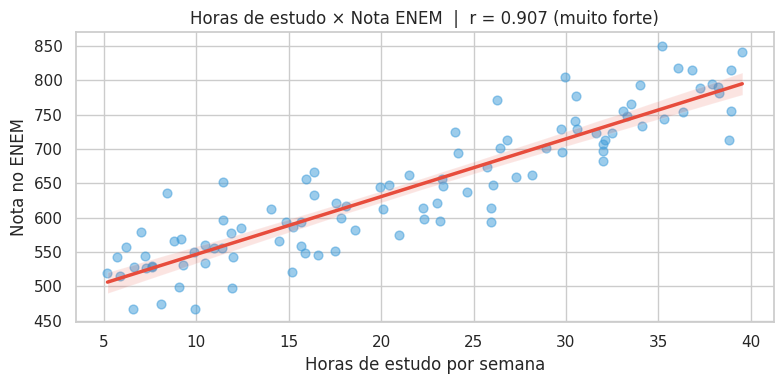

In [ ]:
# ── Correlação de Pearson: mede relação LINEAR ────────────────────────────────
#
# Ideal quando:
# ✓ As duas variáveis são numéricas e contínuas
# ✓ A relação entre elas parece uma reta no gráfico de dispersão
# ✓ Não há outliers extremos (Pearson é sensível a isso)

np.random.seed(42)
n = 100

# Criando dados de horas de estudo × nota no ENEM
horas = np.random.uniform(5, 40, n)   # horas semanais de estudo (5 a 40)

# A nota depende das horas (relação positiva) mais um ruído aleatório
# clip(300, 900) limita os valores entre 300 e 900 (faixa real do ENEM)
notas = (450 + 9.0 * horas + np.random.normal(0, 45, n)).clip(300, 900)

df_enem = pd.DataFrame({'horas_estudo': horas, 'nota_enem': notas})

# .corr() calcula a correlação de Pearson por padrão
r = df_enem['horas_estudo'].corr(df_enem['nota_enem'])

# stats.pearsonr() retorna também o p-valor
# p-valor: probabilidade de observar essa correlação por acaso se não houvesse relação
# p < 0.05 = correlação estatisticamente significativa (muito improvável ser coincidência)
r_val, p_val = stats.pearsonr(horas, notas)

print('=== Correlação de Pearson: horas de estudo × ENEM ===')
print(f'r de Pearson: {r:.3f}')
print(f'p-valor:      {p_val:.2e}   (menor que 0.05 → correlação significativa)')
print()

# Classificando a intensidade
if abs(r) < 0.20:   intensidade = 'muito fraca'
elif abs(r) < 0.40: intensidade = 'fraca'
elif abs(r) < 0.60: intensidade = 'moderada'
elif abs(r) < 0.80: intensidade = 'forte'
else:               intensidade = 'muito forte'

print(f'Classificação: correlação {intensidade}')
print(f'Interpretação: quem estuda mais horas tende a tirar nota maior.')

# Gráfico de dispersão com linha de tendência
plt.figure(figsize=(8, 4))

# sns.regplot = scatter + linha de regressão linear (linha de tendência)
# scatter_kws = configurações dos pontos | line_kws = configurações da linha
sns.regplot(data=df_enem,
            x='horas_estudo',
            y='nota_enem',
            scatter_kws={'alpha': 0.5, 'color': '#3a9ad9', 's': 40},
            line_kws={'color': '#e74c3c', 'linewidth': 2.5})

plt.title(f'Horas de estudo × Nota ENEM  |  r = {r:.3f} ({intensidade})', fontsize=12)
plt.xlabel('Horas de estudo por semana')
plt.ylabel('Nota no ENEM')
plt.tight_layout()
plt.show()

=== Pearson vs. Spearman — relação curvilínea (retornos decrescentes) ===
Pearson (linear):         r = 0.931
Spearman (por rankings):  ρ = 0.959

Spearman captura melhor a relação crescente, mesmo que não seja uma reta.
Pearson subestima porque tenta encaixar uma reta onde há uma curva.


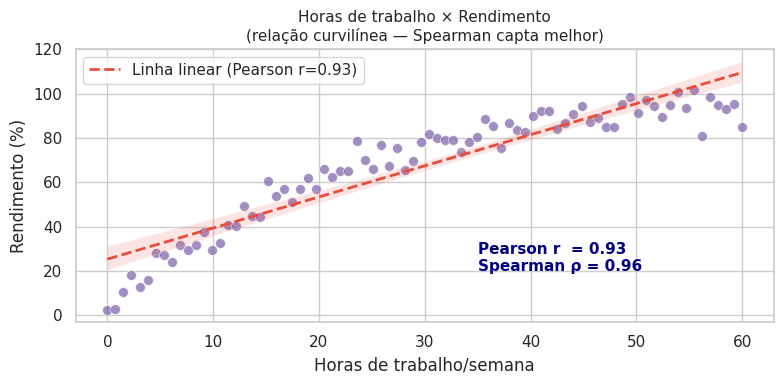

In [ ]:
# ── Correlação de Spearman: mais robusta, usa rankings ────────────────────────
#
# Spearman não usa os valores diretamente — usa a POSIÇÃO de cada valor no ranking.
# Quem tem o maior valor vira posição 1, o segundo maior vira posição 2, etc.
#
# Vantagens:
# ✓ Funciona mesmo com outliers (eles não distorcem os rankings tanto)
# ✓ Funciona para dados ordinais (avaliações 1-5, posições num ranking)
# ✓ Funciona para relações curvilíneas (não precisa ser reta)

np.random.seed(42)

# Cenário: rendimento profissional × horas de trabalho por semana
# Nas primeiras horas, mais trabalho = mais produção.
# Mas depois de um limite, rendimento para de crescer (lei dos retornos decrescentes).
# Essa relação NÃO é uma reta — é uma curva.

horas_trab = np.linspace(0, 60, 80)   # de 0 a 60 horas semanais

# np.exp(-horas/20) cria uma curva que sobe rápido no início e vai desacelerando
rendimento = 100 * (1 - np.exp(-horas_trab / 20)) + np.random.normal(0, 5, 80)

df_trab = pd.DataFrame({'horas': horas_trab, 'rendimento': rendimento})

# Calculando os dois coeficientes
r_pearson  = df_trab['horas'].corr(df_trab['rendimento'], method='pearson')
r_spearman = df_trab['horas'].corr(df_trab['rendimento'], method='spearman')

print('=== Pearson vs. Spearman — relação curvilínea (retornos decrescentes) ===')
print(f'Pearson (linear):         r = {r_pearson:.3f}')
print(f'Spearman (por rankings):  ρ = {r_spearman:.3f}')
print()
print('Spearman captura melhor a relação crescente, mesmo que não seja uma reta.')
print('Pearson subestima porque tenta encaixar uma reta onde há uma curva.')

# Visualizando: scatter + linha de regressão LINEAR (Pearson)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_trab, x='horas', y='rendimento',
                color='#7b5ea7', alpha=0.7, s=50)  # s = tamanho dos pontos

# Adicionando a linha de tendência linear (como Pearson a vê)
sns.regplot(data=df_trab, x='horas', y='rendimento',
            scatter=False,   # scatter=False = só a linha, sem os pontos (já plotamos acima)
            color='#e74c3c',
            line_kws={'linestyle':'--', 'linewidth':2},
            label=f'Linha linear (Pearson r={r_pearson:.2f})')

plt.title('Horas de trabalho × Rendimento\n(relação curvilínea — Spearman capta melhor)', fontsize=11)
plt.xlabel('Horas de trabalho/semana')
plt.ylabel('Rendimento (%)')
plt.legend()
# Adicionando os dois valores no gráfico
plt.text(35, 20, f'Pearson r  = {r_pearson:.2f}\nSpearman ρ = {r_spearman:.2f}',
         fontsize=11, color='navy', fontweight='bold')
plt.tight_layout()
plt.show()

=== CORRELAÇÃO ESPÚRIA: sorvete × afogamentos ===
r(sorvetes × afogamentos)  = 0.852  ← alta, mas NÃO há causalidade!
r(temperatura × sorvetes)  = 0.962  ← temperatura CAUSA o consumo ✅
r(temperatura × afogamentos) = 0.850 ← temperatura CAUSA afogamentos ✅

Conclusão: sorvete e afogamentos são dois EFEITOS da mesma CAUSA (calor).
Reduzir venda de sorvete NÃO reduziria afogamentos.


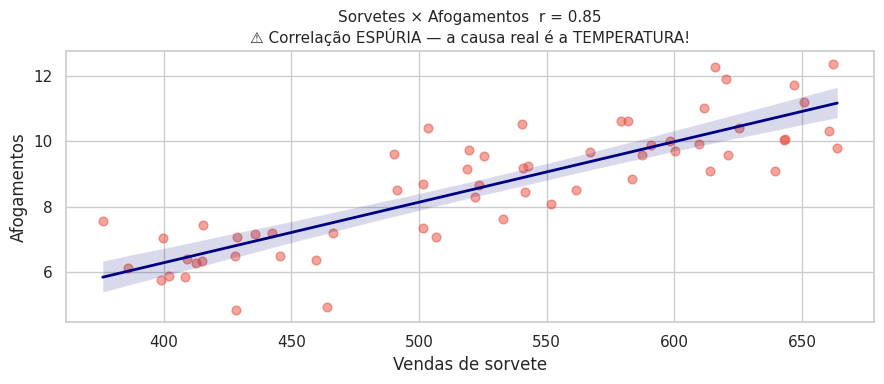

In [ ]:
# ── Correlação ≠ Causalidade — o exemplo clássico ────────────────────────────
#
# Alta correlação entre X e Y pode acontecer por 3 razões:
# 1. X causa Y  (ex: mais estudo → nota maior) ✅ causalidade real
# 2. Y causa X  (causalidade inversa)
# 3. Uma variável Z causa AMBOS — chamamos de 'variável confundidora'

np.random.seed(42)
meses = np.arange(60)  # 5 anos de dados mensais

# Temperatura: sobe no verão, cai no inverno (padrão sazonal)
# np.sin cria uma onda — valores sobem e descem ciclicamente
temperatura = 22 + 8 * np.sin(2 * np.pi * meses / 12) + np.random.normal(0, 1, 60)

# Sorvete: causado pela temperatura (mais calor → mais sorvete)
sorvetes = (200 + 15 * temperatura + np.random.normal(0, 25, 60)).clip(0)

# Afogamentos: também causado pela temperatura (mais calor → mais praia → mais afogamentos)
afogamentos = (2 + 0.3 * temperatura + np.random.normal(0, 1, 60)).clip(0)

# Calculando correlações
r_sorv_afog = pd.Series(sorvetes).corr(pd.Series(afogamentos))   # correlação espúria
r_temp_sorv = pd.Series(temperatura).corr(pd.Series(sorvetes))  # causa real
r_temp_afog = pd.Series(temperatura).corr(pd.Series(afogamentos)) # causa real

print('=== CORRELAÇÃO ESPÚRIA: sorvete × afogamentos ===')
print(f'r(sorvetes × afogamentos)  = {r_sorv_afog:.3f}  ← alta, mas NÃO há causalidade!')
print(f'r(temperatura × sorvetes)  = {r_temp_sorv:.3f}  ← temperatura CAUSA o consumo ✅')
print(f'r(temperatura × afogamentos) = {r_temp_afog:.3f} ← temperatura CAUSA afogamentos ✅')
print()
print('Conclusão: sorvete e afogamentos são dois EFEITOS da mesma CAUSA (calor).')
print('Reduzir venda de sorvete NÃO reduziria afogamentos.')

# Scatter: sorvetes × afogamentos (parece que há relação!)
plt.figure(figsize=(9, 4))
sns.regplot(x=sorvetes, y=afogamentos,
            scatter_kws={'alpha':0.5, 's':40, 'color':'#e74c3c'},
            line_kws={'color':'navy', 'linewidth':2})
plt.title(f'Sorvetes × Afogamentos  r = {r_sorv_afog:.2f}\n⚠️ Correlação ESPÚRIA — a causa real é a TEMPERATURA!',
          fontsize=11)
plt.xlabel('Vendas de sorvete')
plt.ylabel('Afogamentos')
plt.tight_layout()
plt.show()

Matriz de correlação (Pearson):
               Idade  Renda  Ticket Médio  Freq. Compras  Satisfação
Idade           1.00   0.51          0.29           0.04        0.19
Renda           0.51   1.00          0.69           0.05        0.37
Ticket Médio    0.29   0.69          1.00           0.17        0.32
Freq. Compras   0.04   0.05          0.17           1.00        0.05
Satisfação      0.19   0.37          0.32           0.05        1.00

Lendo a matriz:
  • Diagonal = 1.00 (cada variável com ela mesma — sempre perfeita)
  • Verde forte = correlação positiva forte
  • Vermelho = correlação negativa
  • Próximo de 0 = sem relação linear


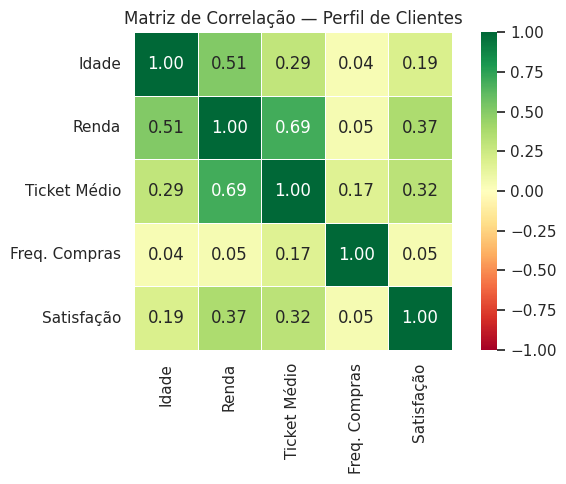

In [ ]:
# ── Matriz de correlação: visualizando todos os pares de uma vez ──────────────
#
# Quando temos várias variáveis, fica inviável calcular cada par separadamente.
# A matriz de correlação calcula todos os pares automaticamente.
# O heatmap a visualiza com cores: verde = positivo, vermelho = negativo.

# Criando um perfil de clientes de e-commerce
np.random.seed(42)
n = 200

idade      = np.random.normal(35, 10, n).clip(18, 70)              # idades
renda      = (1500 + 80*idade + np.random.normal(0, 1500, n)).clip(1320)  # renda depende da idade
ticket     = (0.05*renda + np.random.normal(0, 80, n)).clip(20)    # ticket depende da renda
freq_comp  = np.random.poisson(4, n).astype(float)                 # frequência independente
satisfacao = (3 + 0.0003*renda + np.random.normal(0, 0.8, n)).clip(1, 5)

df_ecomm = pd.DataFrame({
    'Idade':         idade,
    'Renda':         renda,
    'Ticket Médio':  ticket,
    'Freq. Compras': freq_comp,
    'Satisfação':    satisfacao,
})

# .corr() calcula Pearson entre TODAS as combinações de colunas
corr = df_ecomm.corr().round(2)

print('Matriz de correlação (Pearson):')
print(corr)
print()
print('Lendo a matriz:')
print('  • Diagonal = 1.00 (cada variável com ela mesma — sempre perfeita)')
print('  • Verde forte = correlação positiva forte')
print('  • Vermelho = correlação negativa')
print('  • Próximo de 0 = sem relação linear')

# Heatmap: visualiza a matriz de correlação com cores
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,      # annot=True: mostra os números dentro de cada célula
    fmt='.2f',       # formato: 2 casas decimais
    cmap='RdYlGn',   # paleta de cores: vermelho-amarelo-verde
    vmin=-1, vmax=1, # escala fixa de -1 a +1
    linewidths=0.5,  # linhas finas entre as células
    square=True      # células quadradas
)
plt.title('Matriz de Correlação — Perfil de Clientes', fontsize=12)
plt.tight_layout()
plt.show()

---
## 🎯 Exercícios para praticar

### Exercício 1 — Notas de uma turma 📝
```python
notas = pd.Series([6.5, 7.0, 8.5, 9.0, 5.0, 10.0, 7.5, 8.0, 6.0, 4.0, 9.5, 7.0])
```
a) Calcule média, mediana, moda e desvio padrão.  
b) Há outliers pelo método IQR?  
c) Plote um histograma com as 3 medidas marcadas como linhas verticais.  
d) A distribuição é simétrica? Qual medida é mais adequada?

### Exercício 2 — Dashboard de vendas 📊
```python
df_ex = pd.DataFrame({
    'categoria':   ['Eletrônicos','Roupas','Livros','Eletrônicos','Casa',
                   'Roupas','Livros','Eletrônicos','Casa','Roupas'],
    'valor_venda': [1200, 150, 80, 2500, 300, 200, 120, 900, 450, 180]
})
```
a) Use `.groupby()` para calcular o total de vendas por categoria.  
b) Crie um gráfico de barras do total por categoria.  
c) Crie um gráfico de pizza com a proporção de cada categoria.  
d) Qual categoria tem o maior **ticket médio** (valor médio por venda)?

### Exercício 3 — Correlação 🔗
```python
publicidade = [1000, 2000, 1500, 3000, 2500, 4000, 3500, 5000, 4500, 6000]
vendas      = [15000, 28000, 22000, 38000, 33000, 48000, 44000, 62000, 57000, 74000]
```
a) Calcule Pearson e Spearman.  
b) Plote o scatter com a linha de tendência.  
c) Essa correlação prova que publicidade *causa* vendas? Justifique.

---
## ✅ Resumo — O que você aprendeu

| Conceito | Ferramenta pandas/numpy | Quando usar |
|----------|------------------------|-------------|
| Média | `serie.mean()` | Dados sem outliers, distribuição simétrica |
| Mediana | `serie.median()` | Outliers presentes, distribuição assimétrica |
| Moda | `serie.mode()[0]` | Dados categóricos ou o valor mais comum |
| Desvio Padrão | `serie.std()` | Medir variação, risco, comparar grupos |
| Resumo rápido | `df.describe()` | Visão geral de qualquer DataFrame |
| Quartis / IQR | `serie.quantile()` | Detectar outliers, descrever distribuição |
| Pearson | `df.corr()` | Relação linear entre variáveis contínuas |
| Spearman | `df.corr(method='spearman')` | Dados ordinais ou com outliers |

**🔑 Os 3 princípios para carregar sempre:**
1. **Medida certa para o tipo certo** — outliers pedem mediana, categórico pede moda
2. **Visualize antes de concluir** — o gráfico revela o que o número esconde
3. **Correlação ≠ Causalidade** — sempre pergunte: existe um mecanismo plausível?

## Mandem suas perguntas e avaliam a aula aqui: https://forms.gle/fi1ELimajsuc63yF8

## Aula teórica: https://drive.google.com/file/d/18jUkEhFos1Trwf6bGLM7EFkRs2FJL5Oi/view?usp=sharing